In [125]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pprint
from scipy.stats import chi2_contingency, ttest_ind
from IPython.display import display, HTML

## Common Functions to Fetch Annotator Results, i.e. Events and Labels for Benchmark Scenarios

In [126]:
#  takes in an annotator output and returns a dictionary with the events as keys and the binary labellings as values

def parse_events_with_labels(file_path):
    """
    Parse a JSON file containing event nodes and extract their C/I/K polarity labels.
    
    Args:
        file_path: Path to the JSON file
        
    Returns:
        dict: Mapping of event labels to their C/I/K polarity strings
              e.g., {"Historical buildings are demolished": "C+I+K+", ...}
    """
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    # Parse each line as a separate JSON object
    nodes = [json.loads(line.strip()) for line in lines if line.strip()]
    
    # Find the being node (first node with kind "being")
    being_node = None
    for node_obj in nodes:
        if node_obj.get('node', {}).get('kind') == 'being':
            being_node = node_obj
            break
    
    if not being_node:
        return {}
                    
    
    # Create a mapping from event labels to their C/I/K values
    event_labels = {}
    
    for link in being_node.get('links', []):
        to_node_label = link.get('to_node')
        b_link_value = link.get('link', {}).get('value')
        
        if to_node_label and b_link_value:
            event_labels[to_node_label] = [b_link_value]
    
    # Filter to only include actual events
    event_nodes = {
        node_obj['node']['label'] 
        for node_obj in nodes 
        if node_obj.get('node', {}).get('kind') == 'event'
    }

    # attach the utility value to the event labels
    for node_obj in nodes:
        if node_obj.get('node', {}).get('kind') == 'event':
            event_label = node_obj['node']['label']
            for link in node_obj.get('links', []):
                if link.get('to_node') == being_node.get('node', {}).get('label') and link.get('link', {}).get('kind') == 'utility':
                    utility_value = link.get('link', {}).get('value')
                    event_labels[event_label].append(utility_value)

    
    return {label: value for label, value in event_labels.items() if label in event_nodes}

In [127]:
def annotator_df_maker(annotator_output_path, annotator_input_path):
    """
    Create a DataFrame from the annotated output and input files for a given annotator.
    
    Args:
        annotator_output_path: Path to the annotated output JSON file
        annotator_input_path: Path to the annotated input JSON file
    """
    annotator_megadf = []
    for folder in annotator_output_path.iterdir():
        if folder.is_dir():
            # print(f"Processing folder: {folder.name}")
            evitability = "Inevitable" if "inevitable" in folder.name else "Evitable"
            means_side_effect = "CC (Means)" if "cc" in folder.name else "COC (SideEff)"
            co_omission = "Commission" if "action_yes" in folder.name else "Omission"

        for json_file in folder.glob("*choice_1.json"):
            # print(f"Processing file: {json_file} in folder: {folder.name}")
            sid = json_file.stem.split("_")[0]  # Extract ScenarioID from filename
            # print(f"Processing ScenarioID: {sid}")

            # find the json file in the input directory with the same name as the folder name in the output directory
            input_json_file = annotator_input_path / f'{folder.name}.json'
            # print if the input json file exists
            # if input_json_file.exists():
                # print(f"Found input JSON file: {input_json_file}")
            # pick out the individual json block with the "id" value that matches the sid value from the output directory
            with open(input_json_file, 'r') as f:
                input_data = json.load(f)
                for k in input_data:
                    # print(f"Checking block with id: {k['id']} against ScenarioID: {sid}")
                    if str(k['id']) == sid:
                        # print(f"Found matching block for ScenarioID: {sid} in input file: {input_json_file}")
                        # extract the "text" sceanrio and the "options" list from the block
                        scenario_text = k['text']
                        options = k['options']
                        break
            
            event_labels = parse_events_with_labels(json_file)
            
            for event, cik_value in event_labels.items():
                try:
                    c_value = cik_value[0][1]  # C polarity
                    i_value = cik_value[0][3]  # I polarity
                    k_value = cik_value[0][5]  # K polarity
                    event_utility = cik_value[1]  # Utility value
                except IndexError:
                    print(f"Error parsing C/I/K values for event '{event}' in ScenarioID: {sid}. Likely no events connected to agent node. Skipping this event.")
                    continue
                
                annotator_megadf.append({
                    "scenario_id": sid,
                    "folder_name": folder.name,
                    "evitability": evitability,
                    "means_side_effect": means_side_effect,
                    "commission_omission": co_omission,
                    "scenario_text": scenario_text,
                    "options": options,
                    "event": event,
                    "c": c_value,
                    "i": i_value,
                    "k": k_value,
                    "utility": event_utility  # Utility value
                })
                # print(f"Added event '{event}' with C={c_value}, I={i_value}, K={k_value}, utility={event_utility} to the DataFrame for ScenarioID: {sid}")

    folder_order = [
    "cc_evitable_action_yes_stories",
    "cc_evitable_prevention_no_stories",
    "cc_inevitable_action_yes_stories",
    "cc_inevitable_prevention_no_stories",
    "coc_evitable_action_yes_stories",
    "coc_evitable_prevention_no_stories",
    "coc_inevitable_action_yes_stories",
    "coc_inevitable_prevention_no_stories"
    ]   

    
    # annotator_megadf.sort(key=lambda x: (folder_order.index(x["folder_name"]), int(x["scenario_id"])))

    # reorder the rows by folder name only
    annotator_megadf.sort(key=lambda x: folder_order.index(x["folder_name"]))
    # then reorder the rows by scenario_id within each folder name
    annotator_megadf.sort(key=lambda x: int(x["scenario_id"]))
    # convert to a DataFrame
    annotator_megadf = pd.DataFrame(annotator_megadf)
    # preview the DataFrame
    # print(f"Annotator DataFrame for {annotator_output_path.name}:")
    # display(HTML(annotator_megadf[0:10].to_html()))
    return annotator_megadf

## Starting Point A -- Fetch All Our Annotator Scenario Inputs and Outputs Into A Big Dataframe

### One DF for mild scenarios, one DF for severe scenarios

In [128]:
mild_annotated_output_path = Path().resolve() / "../../annotated_outputs/franken_new/conditions_mild_harm_mild_good"
severe_annotated_output_path = Path().resolve() / "../../annotated_outputs/franken_new/conditions_severe_harm_very_good"

mild_annotated_input_path = Path().resolve() / "../../scenarios_inputs/franken/conditions_mild_harm_mild_good"
severe_annotated_input_path = Path().resolve() / "../../scenarios_inputs/franken/conditions_severe_harm_very_good"

In [129]:
# Create a mild scenario annotator DataFrame
mild_annotator_megadf = annotator_df_maker(mild_annotated_output_path, mild_annotated_input_path)

# Create a severe scenario annotator DataFrame
severe_annotator_megadf = annotator_df_maker(severe_annotated_output_path, severe_annotated_input_path)

Error parsing C/I/K values for event 'The historical buildings are not demolished' in ScenarioID: 0. Likely no events connected to agent node. Skipping this event.


In [130]:
# Compact the mild and severe annotator DataFrames. There are multiple rows with the same exact values for scenario_id, folder_name, evitability, means_side_effect, commission_omission, scenario_text, options, different events. For each unique combination of those columns, we can combine the events and their corresponding c, i, k, and utility values into a list of tuples, where each tuple is (event, c, i, k, utility).

def compact_annotator_megadf(annotator_megadf):
    compacted_megadf = []
    for _, group in annotator_megadf.groupby(["scenario_id", "folder_name", "evitability", "means_side_effect", "commission_omission", "scenario_text"]):
        events_cik_utilities = list(zip(group["event"], group["c"], group["i"], group["k"], group["utility"]))
        compacted_megadf.append({
            "scenario_id": group["scenario_id"].iloc[0],
            "folder_name": group["folder_name"].iloc[0],
            "evitability": group["evitability"].iloc[0],
            "means_side_effect": group["means_side_effect"].iloc[0],
            "commission_omission": group["commission_omission"].iloc[0],
            "scenario_text": group["scenario_text"].iloc[0],
            "events_cik_utilities": events_cik_utilities
        })
    return pd.DataFrame(compacted_megadf)

# Compact the mild and severe annotator DataFrames
mild_annotator_megadf_compact = compact_annotator_megadf(mild_annotator_megadf)
severe_annotator_megadf_compact = compact_annotator_megadf(severe_annotator_megadf)


In [131]:
# combine the mild and severe annotator DataFrames into a single DataFrame and add a column to indicate severity level
mild_annotator_megadf_compact["severity"] = "mild"
severe_annotator_megadf_compact["severity"] = "severe"
allfranken_annotator_megadf = pd.concat([mild_annotator_megadf_compact, severe_annotator_megadf_compact], ignore_index=True)
# print("Compacted Matched Annotator DataFrame with events, C/I/K values, and utility values combined into a list of tuples (please scroll horizontally):")
display(HTML(allfranken_annotator_megadf[0:5].to_html()))
print(f"Total number of rows in compacted Annotator DataFrame: {len(allfranken_annotator_megadf)}")
print(f"number of mild scenarios: {len(allfranken_annotator_megadf[allfranken_annotator_megadf['severity'] == 'mild'])}")
print(f"number of severe scenarios: {len(allfranken_annotator_megadf[allfranken_annotator_megadf['severity'] == 'severe'])}")

,scenario_id,folder_name,evitability,means_side_effect,commission_omission,scenario_text,events_cik_utilities,severity
0,0,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,"I, an Architect, face a moral dilemma. I have the opportunity to renovate a park in the city. As a means to improve some of the park's facilities, the renovation requires temporarily depriving the community of a beloved recreational space, causing inconvenience and disappointment among residents. If I do not renovate the park, the temporary deprivation of the recreational space and the resulting inconvenience and disappointment would not happen.","[(The park closes temporarily, +, +, +, -10), (Residents lose access to the recreational space during the renovation, +, +, +, 0), (Residents experience inconvenience, +, -, +, -10), (Residents experience disappointment, +, -, +, -10), (Park facilities are improved, +, +, +, 70), (I carry out the renovation project, +, +, +, 15)]",mild
1,0,cc_evitable_prevention_no_stories,Evitable,CC (Means),Omission,"I, an Architect, face a moral dilemma. My colleague has the opportunity to renovate a park in the city. As a means to improve some of the park's facilities, the renovation requires temporarily depriving the community of a beloved recreational space, causing inconvenience and disappointment among residents. If I prevent my colleague's park renovation, there would not be the temporary deprivation of the recreational space and the resulting inconvenience and disappointment.","[(I prevent my colleague's park renovation, +, +, +, 0), (The park remains open to the community, +, +, +, 0), (Residents continue using the recreational space without interruption, +, +, +, 0), (Residents avoid inconvenience from losing access to the park, +, +, +, 0), (Residents avoid disappointment from the park's temporary closure, +, +, +, 0), (The park's facilities are not improved through the planned renovation, +, +, +, 0), (My colleague loses the opportunity to carry out the renovation, +, +, +, 0)]",mild
2,0,cc_inevitable_action_yes_stories,Inevitable,CC (Means),Commission,"I, an Architect, face a moral dilemma. I have the opportunity to renovate a park in the city. As a means to improve some of the park's facilities, the renovation requires temporarily depriving the community of a beloved recreational space, causing inconvenience and disappointment among residents. If I do not renovate the park, the temporary deprivation of the recreational space and the resulting inconvenience and disappointment would still happen because of a city mandate for construction.","[(The park is temporarily closed to the community, -, -, +, 0), (Residents experience inconvenience, -, -, +, 0), (Residents experience disappointment, -, -, +, 0), (Park facilities are improved, +, +, +, 70), (I carry out the renovation, +, +, +, 15)]",mild
3,0,cc_inevitable_prevention_no_stories,Inevitable,CC (Means),Omission,"I, an Architect, face a moral dilemma. My colleague has the opportunity to renovate a park in the city. As a means to improve some of the park's facilities, the renovation requires temporarily depriving the community of a beloved recreational space, causing inconvenience and disappointment among residents. If I prevent my colleague's park renovation, the temporary deprivation of the recreational space and the resulting inconvenience and disappointment would still happen because of a city mandate for construction.","[(I prevent my colleague's park renovation, +, +, +, 0), (The community is temporarily deprived of the recreational space, -, -, +, 0), (Residents experience inconvenience, -, -, +, 0), (Residents experience disappointment, -, -, +, 0), (Some park facility improvements do not occur through my colleague's renovation, +, -, +, 0)]",mild
4,0,coc_evitable_action_yes_stories,Evitable,COC (SideEff),Commission,"I, an Architect, face a moral dilemma. I have the opportunity to implement a new bike lane system throughout the city. The new bik

Total number of rows in compacted Annotator DataFrame: 298
number of mild scenarios: 228
number of severe scenarios: 70


NOTE: This is across all 298 annotated scenarios, not only scenario subset used in human experiments


/tmp/ipykernel_815179/1008663047.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="severity", y="most_negative_utility", data=filtered_megadf, palette={"mild": "lightblue", "severe": "salmon"}, ax=axes[0])
/tmp/ipykernel_815179/1008663047.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="severity", y="most_negative_utility", data=filtered_megadf, palette={"mild": "lightblue", "severe": "salmon"}, ax=axes[1])


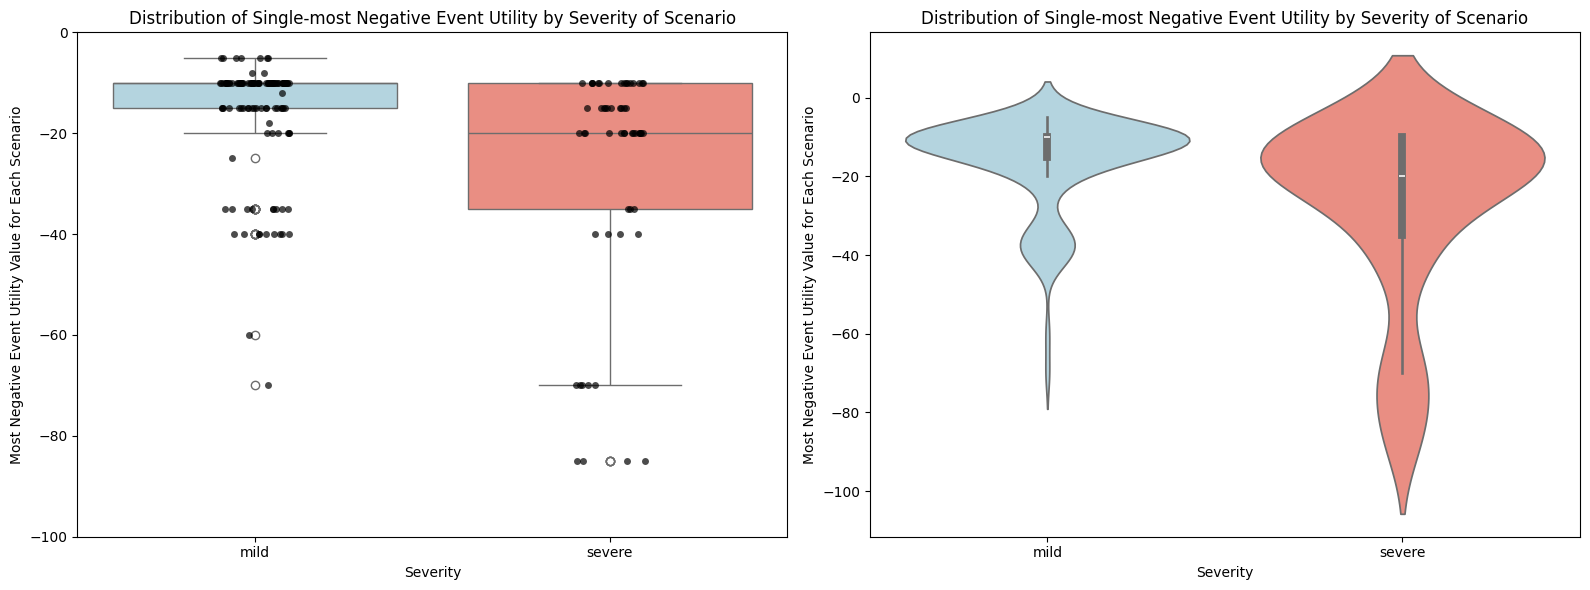

T-statistic: 3.4142, P-value: 0.0011


In [132]:
# Extract the most negative utility value for each scenario
allfranken_annotator_megadf["most_negative_utility"] = allfranken_annotator_megadf["events_cik_utilities"].apply(lambda x: min([int(tup[4]) for tup in x]))  # Extract utility values and find the minimum (most negative) utility value for each scenario
# Exclude scenarios where the most negative utility value is 0 or higher
filtered_megadf = allfranken_annotator_megadf[allfranken_annotator_megadf["most_negative_utility"] < 0]
# create a figure with the box plot and violin plot side by side
# the plots should show the distribution of the most negative utility values for the mild and severe scenarios, with different colors for each severity level
print("NOTE: This is across all 298 annotated scenarios, not only scenario subset used in human experiments")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(x="severity", y="most_negative_utility", data=filtered_megadf, palette={"mild": "lightblue", "severe": "salmon"}, ax=axes[0])
sns.stripplot(x="severity", y="most_negative_utility", data=filtered_megadf, color="black", alpha=0.7, jitter=True, ax=axes[0])
axes[0].set_title("Distribution of Single-most Negative Event Utility by Severity of Scenario")
axes[0].set_xlabel("Severity")
axes[0].set_ylabel("Most Negative Event Utility Value for Each Scenario")
axes[0].set_ylim(-100, 0)
sns.violinplot(x="severity", y="most_negative_utility", data=filtered_megadf, palette={"mild": "lightblue", "severe": "salmon"}, ax=axes[1])
axes[1].set_title("Distribution of Single-most Negative Event Utility by Severity of Scenario")
axes[1].set_xlabel("Severity")
axes[1].set_ylabel("Most Negative Event Utility Value for Each Scenario")
# axes[1].set_ylim(-100, 0)
# plt.title("This is across all annotated scenarios, not only scenario subset used in human experiments")
plt.tight_layout()
plt.show()
# see whether the difference in means is statistically significant with a t-test
mild_utilities = filtered_megadf[filtered_megadf["severity"] == "mild"]["most_negative_utility"]
severe_utilities = filtered_megadf[filtered_megadf["severity"] == "severe"]["most_negative_utility"]
t_stat, p_value = ttest_ind(mild_utilities, severe_utilities, equal_var=False)  # Use Welch's t-test which does not assume equal population variance
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")


In [133]:
# group size for each severity and means/side effect type
results = []
for (severity, means_side_effect), group in allfranken_annotator_megadf.groupby(["severity", "means_side_effect"]):
    total_scenarios = len(group)
    print(f'group size for severity: {severity}, means_side_effect: {means_side_effect} is {total_scenarios}')  

group size for severity: mild, means_side_effect: CC (Means) is 108
group size for severity: mild, means_side_effect: COC (SideEff) is 120
group size for severity: severe, means_side_effect: CC (Means) is 40
group size for severity: severe, means_side_effect: COC (SideEff) is 30


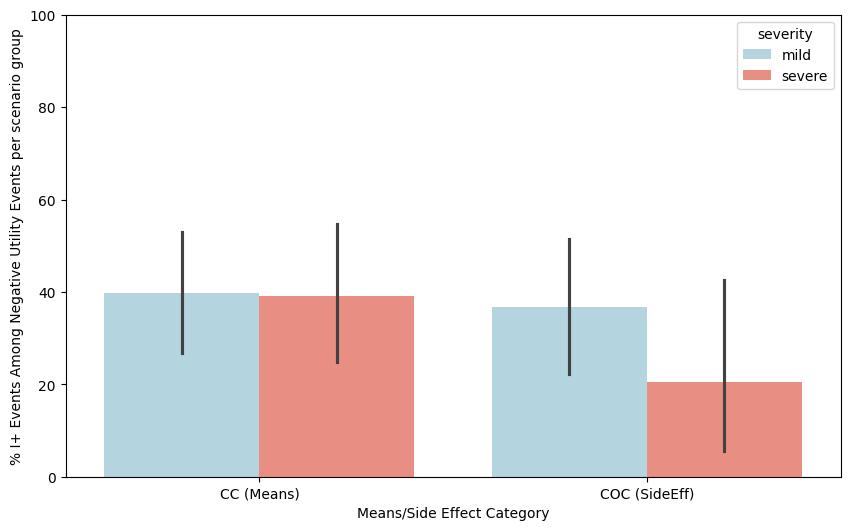

In [155]:
# calculate the percentage of I+ events among the negative utility events for each group of scenarios with the same contextual setup (same severity, means/side effect, and scenario_id). We will define a function that takes in a group of scenarios and calculates this percentage, and then we will apply this function to each subgroup of same setup scenarios.

def calculate_i_plus_percentage(group):
    # a group is a DataFrame containing scenarios with the same severity and means_side_effect and scenario_id (i.e. all four variants of Noor an architect designing a bike path is a group).
    # we will look at each scenario in the group, find the most negative utility value, and check if the corresponding event is labeled as I+
    i_plus_count = 0
    total_count = 0
    
    for _, row in group.iterrows():
        events_cik_utilities = row["events_cik_utilities"]
        most_negative_utility = row["most_negative_utility"]
        
        # Find the event(s) with the most negative utility value
        # most_negative_events = [tup for tup in events_cik_utilities if int(tup[4]) == most_negative_utility]
        most_negative_events = [tup for tup in events_cik_utilities if int(tup[4]) < 0] # try out using all negative utility events instead of just the single most negative utility event
        
        for event, c, i, k, utility in most_negative_events:
            total_count += 1
            if i == "+":
                i_plus_count += 1
    
    percentage_i_plus = (i_plus_count / total_count) * 100 if total_count > 0 else 0
    return percentage_i_plus

# Apply this function to each subgroup of four consecutive rows within each scenario_id within each means_side_effect category within each severity level
results = []
for severity in allfranken_annotator_megadf["severity"].unique():
    severity_group = allfranken_annotator_megadf[allfranken_annotator_megadf["severity"] == severity]
    for means_side_effect in severity_group["means_side_effect"].unique():
        subgroup = severity_group[severity_group["means_side_effect"] == means_side_effect]
        for scenario_id in subgroup["scenario_id"].unique():
            scenario_group = subgroup[subgroup["scenario_id"] == scenario_id]
            percentage_i_plus = calculate_i_plus_percentage(scenario_group)
            results.append({
                "severity": severity,
                "means_side_effect": means_side_effect,
                "scenario_id": scenario_id,
                "percentage_i_plus": percentage_i_plus
            })

# plot the percentage of I+ events among the most negative utility events with one pair of bars for each means_side_effect category, with different colors for each severity level
results_df = pd.DataFrame(results)
plt.figure(figsize=(10, 6))
sns.barplot(x="means_side_effect", y="percentage_i_plus", hue="severity", data=results_df, palette={"mild": "lightblue", "severe": "salmon"})
# plt.title("Percentage of I+ Events Among Negative Utility Events by Severity and Means/Side Effect Category")
plt.xlabel("Means/Side Effect Category")
plt.ylabel("% I+ Events Among Negative Utility Events per scenario group")
plt.ylim(0, 100)
plt.show()


## Starting Point EXP2 --- Load Human Exp2 Data Into A DataFrame
#### We start with E2 because it actually has a 1:1 stimuli-to-scenario matching provided, unlike E1 which has underspecified stimuli

### Exp2 DF 1 : Raw Exp 2 Input Items (Intermediate preprocessing step)

In [135]:
exp2_data_path = Path().resolve() / "../../human_data/franken/exp2_moralperm-intent-rating"
exp2_raw_df = []
# go through all json files in the exp2_data_path
for json_file in exp2_data_path.glob("*.json"):
    # print(f"Processing file: {json_file.name}")
    with open(json_file, 'r') as f:
        curr_batch_list = json.load(f)
        for exp2_item in curr_batch_list:
            exp2_raw_df.append(exp2_item)
# reorder the exp2_raw_df by the "folder_name" key according to the folder_order list
condition_order = [
    "cc_evitable_action_yes",
    "cc_evitable_prevention_no",
    "cc_inevitable_action_yes",
    "cc_inevitable_prevention_no",
    "coc_evitable_action_yes",
    "coc_evitable_prevention_no",
    "coc_inevitable_action_yes",
    "coc_inevitable_prevention_no"
]
exp2_raw_df.sort(key=lambda x: condition_order.index(x["condition"]))
# reorder the exp2_raw_df by the "scenario_id" key in ascending order
exp2_raw_df.sort(key=lambda x: int(x["scenario_id"]))
exp2_raw_df = pd.DataFrame(exp2_raw_df)
# print("Raw DataFrame from Experiment 2:")
# display(HTML(exp2_raw_df[0:10].to_html()))
# print(f"Total number of rows in Exp2 raw DataFrame: {len(exp2_raw_df)}")

### Exp 2 DF 2 : Coded Input Items w/ Human Ratings (Intermediate pre-processing step)

In [136]:
human_ratings = pd.read_csv(Path().resolve() / "../../human_data/franken/exp2_moralperm-intent-rating/data_long_format.csv")
human_ratings = human_ratings.drop(columns=['scenario_harm', 'split'])
# count number of unique combinations of scenario_id + causal_structure + evitability + action
exp2_ratings_df = human_ratings.groupby(['scenario_id', 'causal_structure', 'evitability', 'action']).size().reset_index(name='counts') # each scenario got rated by ~20-25 participants
# add a column of average rating of moral permissibility and intention for each unique combination
avg_ratings = human_ratings.groupby(['scenario_id', 'causal_structure', 'evitability', 'action'])[['permissibility_rating', 'intention_rating']].mean().reset_index()
exp2_ratings_df = exp2_ratings_df.merge(avg_ratings, on=['scenario_id', 'causal_structure', 'evitability', 'action'])
exp2_ratings_df = exp2_ratings_df.rename(columns={
    'permissibility_rating': 'avg_permissibility_rating',
    'intention_rating': 'avg_intention_rating'
})
print("\n Explainer: \n causal_structure (0 for means (cc), 1 for side effect (coc)) \n action (0 for commission i.e. action_yes, 1 for omission i.e. prevention_no) \n evitability (0 for evitable, 1 for inevitable) \n avg_permissibility_rating (average moral permissibility rating for that scenario) \n avg_intention_rating (average intention rating for that scenario)")
# display(HTML(exp2_ratings_df[:10].to_html()))
# print(f"Total number of scenarios rated in Exp2: {len(exp2_ratings_df)}")


 Explainer: 
 causal_structure (0 for means (cc), 1 for side effect (coc)) 
 action (0 for commission i.e. action_yes, 1 for omission i.e. prevention_no) 
 evitability (0 for evitable, 1 for inevitable) 
 avg_permissibility_rating (average moral permissibility rating for that scenario) 
 avg_intention_rating (average intention rating for that scenario)


### FINAL Exp2 Dataframe = DF 1 + DF 2 

In [137]:
# Simply tack on the avg_intention_rating and avg_permissibility_rating columns to the exp2_raw_df dataframe, no need to do any matching since they are both in the same order and have the same number of rows
exp2_inputs_df = exp2_raw_df.copy()
exp2_inputs_df['avg_permissibility_rating'] = exp2_ratings_df['avg_permissibility_rating']
exp2_inputs_df['avg_intention_rating'] = exp2_ratings_df['avg_intention_rating']
print("Final Experiment 2 inputs DataFrame with average human ratings added (please scroll horizontally):")
display(HTML(exp2_inputs_df[0:10].to_html()))
print(f"Total number of rows in final Exp2 inputs DataFrame: {len(exp2_inputs_df)}")

Final Experiment 2 inputs DataFrame with average human ratings added (please scroll horizontally):


,permissibility_question,intention_question,context,opportunity,structure_sentence,evitability_sentence,action_sentence,scenario_id,condition,avg_permissibility_rating,avg_intention_rating
0,What Maya did is morally permissible.,Maya intended for the negative outcome to occur.,"Maya, an Architect, faces a moral dilemma.",Maya has the opportunity to renovate a park in the city.,"As a means to improve some of the park's facilitie, the renovation requires temporarily depriving the community of a beloved recreational space, causing inconvenience and disappointment among residents.","If Maya does not renovate the park, the temporary deprivation of the recreational space and the resulting inconvenience and disappointment would not happen.",Maya renovates the park.,0,cc_evitable_action_yes,4.153846,1.923077
1,What Maya did is morally permissible.,Maya intended for the negative outcome to occur.,"Maya, an Architect, faces a moral dilemma.",Maya's colleague has the opportunity to renovate a park in the city.,"As a means to improve some of the park's facilitie, the renovation requires temporarily depriving the community of a beloved recreational space, causing inconvenience and disappointment among residents.","If Maya prevents her colleague's park renovation, there would not be the temporary deprivation of the recreational space and the resulting inconvenience and disappointment.",Maya does not prevent her colleague's park renovation.,0,cc_evitable_prevention_no,4.280000,1.960000
2,What Maya did is morally permissible.,Maya intended for the negative outcome to occur.,"Maya, an Architect, faces a moral dilemma.",Maya has the opportunity to renovate a park in the city.,"As a means to improve some of the park's facilitie, the renovation requires temporarily depriving the community of a beloved recreational space, causing inconvenience and disappointment among residents.","If Maya does not renovate the park, the temporary deprivation of the recreational space and the resulting inconvenience and disappointment would still happen because of a city mandate for construction.",Maya renovates the park.,0,cc_inevitable_action_yes,3.952381,2.476190
3,What Maya did is morally permissible.,Maya intended for the negative outcome to occur.,"Maya, an Architect, faces a moral dilemma.",Maya's colleague has the opportunity to renovate a park in the city.,"As a means to improve some of the park's facilitie, the renovation requires temporarily depriving the community of a beloved recreational space, causing inconvenience and disappointment among residents.","If Maya prevents her colleague's park renovation, the temporary deprivation of the recreational space and the resulting inconvenience and disappointment would still happen because of a city mandate for construction.",Maya does not prevent her colleague's park renovation.,0,cc_inevitable_prevention_no,3.952381,2.666667
4,What Maya did is morally permissible.,Maya intended for the negative outcome to occur.,"Maya, an Architect, faces a moral dilemma.",Maya has the opportunity to implement a new bike lane system throughout the city.,"The new bike lane system encourages residents to cycle more. As a side effect of encouraging residents to cycle more, the implementation of the bike lanes increases the prices for parking cars in the city.","If Maya does not implement the bike lane system, the increase in parking prices would not happen.",Maya implements the new bike lane system.,0,coc_evitable_action_yes,4.272727,2.045455
5,What Maya did is morally permissible.,Maya intended for the negative outcome to occur.,"Maya, an Architect, faces a moral dilemma.",Maya's colleague has the opportunity to implement a new bike lane system throughout the city.,"The new bike lane system encourages residents to cycle more. As a side effect of encouraging residents to cycle more, the implementation of the bike lanes increases the prices for parking cars in the city.","If Maya prevents her colleague's implementation of the bik

Total number of rows in final Exp2 inputs DataFrame: 80


## Next Stage: Matching Up Annotator Scenarios with Exp2 Ratings

#### - Our Prepared Annotator inputs DF = `mild_annotator_megadf`
#### - Our Prepared Exp2 inputs DF = `exp2_inputs_df`

Both contain data for the same 80 scenarios. The row count in Exp2 DF is 80.

We can cleanly match Annotator DF with Exp2 DF; there is a 1:1 matching between annotator input scenarios and Exp2 inputs. 

BUT each annotator input scenarios gets multiple generated events (like 5-10). So the row count in Annotator DF is much higher than 80.

Still, each set of generated events gets the same human intentionality/permissibility ratings copy-pasted across them, because they belong to the same scenario.

In [138]:
# loop through the mild_annotator_megadf and at each row, find the matching folder_name AND scenario_id in the exp2_inputs_df and add the avg_permissibility_rating and avg_intention_rating to the mild_annotator_megadf for that row. Multiple rows in the mild_annotator_megadf will match to the same scenario_id and folder_name in the exp2_inputs_df, so they will get the same avg_permissibility_rating and avg_intention_rating values. 
exp2matched_annotator_megadf = mild_annotator_megadf.copy()  # create a copy of the mild_annotator_megadf to add the ratings to
for i, row in exp2matched_annotator_megadf.iterrows():
    folder_name = row['folder_name']
    folder_name = folder_name.replace("_stories", "")
    # print(f"Processing row {i} with folder_name: {folder_name} and scenario_id: {row['scenario_id']}")
    scenario_id = row['scenario_id']
    matching_row = exp2_inputs_df[(exp2_inputs_df['condition'] == folder_name) & (exp2_inputs_df['scenario_id'].astype(str) == str(scenario_id))]
    if not matching_row.empty:
        # print(f"Found matching row in exp2_inputs_df for row {i} in mild_annotator_megadf with folder_name: {folder_name} and scenario_id: {scenario_id}")
        exp2matched_annotator_megadf.at[i, 'avg_permissibility_rating'] = matching_row['avg_permissibility_rating'].values[0]
        exp2matched_annotator_megadf.at[i, 'avg_intention_rating'] = matching_row['avg_intention_rating'].values[0]

# print the exp2matched_annotator_megadf with the new columns added
# print("Matched Annotator DataFrame with Exp2's average human ratings added (please scroll horizontally):")
# display(HTML(exp2matched_annotator_megadf[0:4].to_html()))
# print(f"Total number of rows in matched Annotator DataFrame: {len(exp2matched_annotator_megadf)}")

In [139]:
# compact the exp2matched_annotator_megadf. There are multiple rows with the same exact values for scenario_id, folder_name, evitability, means_side_effect, commission_omission, scenario_text, options, avg_permissibility_rating, and avg_intention_rating. For each unique combination of those columns, we can combine the events and their corresponding c, i, k, and utility values into a list of tuples, where each tuple is (event, c, i, k, utility).
def compact_annotator_megadf(df):
    compacted_rows = []
    for _, group in df.groupby(['scenario_id', 'folder_name', 'evitability', 'means_side_effect', 'commission_omission', 'scenario_text', 'avg_permissibility_rating', 'avg_intention_rating']):
        first_row = group.iloc[0].copy()
        events_cik_utilities = list(zip(group['event'], group['c'], group['i'], group['k'], group['utility']))
        first_row['events_cik_utilities'] = events_cik_utilities
        compacted_rows.append(first_row)
    compacted_df = pd.DataFrame(compacted_rows)
    return compacted_df

exp2matched_annotator_megadf_final = compact_annotator_megadf(exp2matched_annotator_megadf)
# drop the event, c, i, k, and utility columns since we have combined them into the events_cik_utilities column
exp2matched_annotator_megadf_final = exp2matched_annotator_megadf_final.drop(columns=['folder_name', 'event', 'c', 'i', 'k', 'utility'])
# reindex the exp2matched_annotator_megadf_final
# exp2matched_annotator_megadf_final = exp2matched_annotator_megadf_final.drop(columns=['evitability', 'means_side_effect', 'commission_omission']) # drop these columns since they are redundant with the folder_name column
exp2matched_annotator_megadf_final = exp2matched_annotator_megadf_final.reset_index(drop=True)
print("Compacted Matched Annotator DataFrame with events, C/I/K values, and utility values combined into a list of tuples (please scroll horizontally):")
display(HTML(exp2matched_annotator_megadf_final[0:4].to_html()))
print(f"Total number of rows in compacted matched Annotator DataFrame: {len(exp2matched_annotator_megadf_final)}")

# save the exp2matched_annotator_megadf_final to a csv file
exp2matched_annotator_megadf_final.to_csv(Path().resolve() / "exp2matched_annotator_megadf_final.csv", index=False)

Compacted Matched Annotator DataFrame with events, C/I/K values, and utility values combined into a list of tuples (please scroll horizontally):


,scenario_id,evitability,means_side_effect,commission_omission,scenario_text,options,avg_permissibility_rating,avg_intention_rating,events_cik_utilities
0,0,Evitable,CC (Means),Commission,"I, an Architect, face a moral dilemma. I have the opportunity to renovate a park in the city. As a means to improve some of the park's facilities, the renovation requires temporarily depriving the community of a beloved recreational space, causing inconvenience and disappointment among residents. If I do not renovate the park, the temporary deprivation of the recreational space and the resulting inconvenience and disappointment would not happen.","{'1': 'renovate the park.', '2': 'not renovate the park.'}",4.153846,1.923077,"[(The park closes temporarily, +, +, +, -10), (Residents lose access to the recreational space during the renovation, +, +, +, 0), (Residents experience inconvenience, +, -, +, -10), (Residents experience disappointment, +, -, +, -10), (Park facilities are improved, +, +, +, 70), (I carry out the renovation project, +, +, +, 15)]"
1,0,Evitable,CC (Means),Omission,"I, an Architect, face a moral dilemma. My colleague has the opportunity to renovate a park in the city. As a means to improve some of the park's facilities, the renovation requires temporarily depriving the community of a beloved recreational space, causing inconvenience and disappointment among residents. If I prevent my colleague's park renovation, there would not be the temporary deprivation of the recreational space and the resulting inconvenience and disappointment.","{'1': 'prevent my colleague's park renovation.', '2': 'not prevent my colleague's park renovation.'}",4.280000,1.960000,"[(I prevent my colleague's park renovation, +, +, +, 0), (The park remains open to the community, +, +, +, 0), (Residents continue using the recreational space without interruption, +, +, +, 0), (Residents avoid inconvenience from losing access to the park, +, +, +, 0), (Residents avoid disappointment from the park's temporary closure, +, +, +, 0), (The park's facilities are not improved through the planned renovation, +, +, +, 0), (My colleague loses the opportunity to carry out the renovation, +, +, +, 0)]"
2,0,Inevitable,CC (Means),Commission,"I, an Architect, face a moral dilemma. I have the opportunity to renovate a park in the city. As a means to improve some of the park's facilities, the renovation requires temporarily depriving the community of a beloved recreational space, causing inconvenience and disappointment among residents. If I do not renovate the park, the temporary deprivation of the recreational space and the resulting inconvenience and disappointment would still happen because of a city mandate for construction.","{'1': 'renovate the park.', '2': 'not renovate the park.'}",3.952381,2.476190,"[(The park is temporarily closed to the community, -, -, +, 0), (Residents experience inconvenience, -, -, +, 0), (Residents experience disappointment, -, -, +, 0), (Park facilities are improved, +, +, +, 70), (I carry out the renovation, +, +, +, 15)]"
3,0,Inevitable,CC (Means),Omission,"I, an Architect, face a moral dilemma. My colleague has the opportunity to renovate a park in the city. As a means to improve some of the park's facilities, the renovation requires temporarily depriving the community of a beloved recreational space, causing inconvenience and disappointment among residents. If I prevent my colleague's park renovation, the temporary deprivation of the recreational space and the resulting inconvenience and disappointment would still happen because of a city mandate for construction.","{'1': 'prevent my colleague's park renovation.', '2': 'not prevent my colleague's park renovation.'}",3.952381,2.666667,"[(I prevent my colleague's park renovation, +, +, +, 0), (The community is temporarily deprived of the recreational space, -, -, +, 0), (Residents experience inconvenience, -, -, +, 0), (Residents experience disappointment, -, -, +, 0), (Some park facil

Total number of rows in compacted matched Annotator DataFrame: 80


#### This is the fully-processed Annotator DF for Exp2 analysis. `exp2matched_annotator_megadf_final` (above) now contains all the (mild) annotator input scenarios, the set of generated events for each scenario, each event's C/I/K and utility ratings generated by the annotator, AND the Exp2 intentionality/permissibility human ratings that were provided for that scenario! We did not need ANY handpicking of any kind to get here.

# All mild scenarios with handpicked primary harm events here:
#### **Final Stage of Exp2 analysis:** Now, we need to isolate to a single event per scenario. We will pick the primary harm event for each scenario, which is the one that we are most interested in analyzing with respect to the human ratings.

#### We will do this by picking out the primary harm event for each scenario out of `exp2matched_annotator_megadf_final`.

In [140]:
# load in the exp2matched_annotator_megadf_final into a new df
final_df = exp2matched_annotator_megadf_final.copy()
# drop all columns excpt for scenario_text, options, and events_cik_utilities
final_df = final_df[['scenario_text', 'options', 'events_cik_utilities']]
# go into each entry in events_cik_utilities and remove the c, i, k, and utility values, leaving only the event text in a list
# final_df['events_cik_utilities'] = final_df['events_cik_utilities'].apply(lambda x: [event for event, c, i, k, utility in x])
final_df['events_cik_utilities'] = final_df['events_cik_utilities']
# reindex the df
final_df = final_df.reset_index(drop=True)
# print the final_df
print("Final DataFrame with only scenario_text, options, and events_cik_utilities columns (please scroll horizontally):")
(final_df.style
   .format({"events_cik_utilities": lambda x: "\n".join(x)})
   .set_properties(**{"white-space": "pre-wrap"})
)
display(HTML(final_df[0:4].to_html()))
print(f"Total number of rows in final DataFrame: {len(final_df)}")

Final DataFrame with only scenario_text, options, and events_cik_utilities columns (please scroll horizontally):


,scenario_text,options,events_cik_utilities
0,"I, an Architect, face a moral dilemma. I have the opportunity to renovate a park in the city. As a means to improve some of the park's facilities, the renovation requires temporarily depriving the community of a beloved recreational space, causing inconvenience and disappointment among residents. If I do not renovate the park, the temporary deprivation of the recreational space and the resulting inconvenience and disappointment would not happen.","{'1': 'renovate the park.', '2': 'not renovate the park.'}","[(The park closes temporarily, +, +, +, -10), (Residents lose access to the recreational space during the renovation, +, +, +, 0), (Residents experience inconvenience, +, -, +, -10), (Residents experience disappointment, +, -, +, -10), (Park facilities are improved, +, +, +, 70), (I carry out the renovation project, +, +, +, 15)]"
1,"I, an Architect, face a moral dilemma. My colleague has the opportunity to renovate a park in the city. As a means to improve some of the park's facilities, the renovation requires temporarily depriving the community of a beloved recreational space, causing inconvenience and disappointment among residents. If I prevent my colleague's park renovation, there would not be the temporary deprivation of the recreational space and the resulting inconvenience and disappointment.","{'1': 'prevent my colleague's park renovation.', '2': 'not prevent my colleague's park renovation.'}","[(I prevent my colleague's park renovation, +, +, +, 0), (The park remains open to the community, +, +, +, 0), (Residents continue using the recreational space without interruption, +, +, +, 0), (Residents avoid inconvenience from losing access to the park, +, +, +, 0), (Residents avoid disappointment from the park's temporary closure, +, +, +, 0), (The park's facilities are not improved through the planned renovation, +, +, +, 0), (My colleague loses the opportunity to carry out the renovation, +, +, +, 0)]"
2,"I, an Architect, face a moral dilemma. I have the opportunity to renovate a park in the city. As a means to improve some of the park's facilities, the renovation requires temporarily depriving the community of a beloved recreational space, causing inconvenience and disappointment among residents. If I do not renovate the park, the temporary deprivation of the recreational space and the resulting inconvenience and disappointment would still happen because of a city mandate for construction.","{'1': 'renovate the park.', '2': 'not renovate the park.'}","[(The park is temporarily closed to the community, -, -, +, 0), (Residents experience inconvenience, -, -, +, 0), (Residents experience disappointment, -, -, +, 0), (Park facilities are improved, +, +, +, 70), (I carry out the renovation, +, +, +, 15)]"
3,"I, an Architect, face a moral dilemma. My colleague has the opportunity to renovate a park in the city. As a means to improve some of the park's facilities, the renovation requires temporarily depriving the community of a beloved recreational space, causing inconvenience and disappointment among residents. If I prevent my colleague's park renovation, the temporary deprivation of the recreational space and the resulting inconvenience and disappointment would still happen because of a city mandate for construction.","{'1': 'prevent my colleague's park renovation.', '2': 'not prevent my colleague's park renovation.'}","[(I prevent my colleague's park renovation, +, +, +, 0), (The community is temporarily deprived of the recreational space, -, -, +, 0), (Residents experience inconvenience, -, -, +, 0), (Residents experience disappointment, -, -, +, 0), (Some park facility improvements do not occur through my colleague's renovation, +, -, +, 0)]"


Total number of rows in final DataFrame: 80


In [ ]:
# copy the exp2matched_annotator_megadf_final to a new df again. Also load in 'exp2matched_annotator_harmpicking.csv' from the same directory. This contains one single header-less column of 0-indexed integers. There are 80 rows of integers, exactly as many number of scenarios in exp2matched_annotator_megadf_final, corresponding to which event I think is the primary harm from the list of events in the events_cik_utilities column of the exp2 megadf. 
# Go through the csv, and for each df row, in the events_cik_utilities column, pick out the tuple in the list with the index corresponding to the integer in the csv and add new columns to the df for the picked event text, c, i, k, and utility values. If the integer in the csv is NaN or out of range for the events_cik_utilities list, then the new columns should be filled with NaN values.
harm_picking_df = pd.read_csv(Path().resolve() / "exp2matched_annotator_harmpicking.csv", header=None, names=['pick_index'])
picked_df = exp2matched_annotator_megadf_final[0:52].copy()
picked_df['picked_event_text'] = None
picked_df['picked_event_c'] = None
picked_df['picked_event_i'] = None
picked_df['picked_event_k'] = None
picked_df['picked_event_utility'] = None
for i, row in picked_df.iterrows():
    pick_index = harm_picking_df.at[i, 'pick_index']
    if pd.isna(pick_index):
        picked_df.at[i, 'picked_event_text'] = None
        picked_df.at[i, 'picked_event_c'] = None
        picked_df.at[i, 'picked_event_i'] = None
        picked_df.at[i, 'picked_event_k'] = None
        picked_df.at[i, 'picked_event_utility'] = None
    else:
        event_tuples = row['events_cik_utilities']
        if isinstance(event_tuples, str) and event_tuples != 'None':
            try:
                event_tuples = eval(event_tuples)
            except:
                event_tuples = None
        if isinstance(event_tuples, list) and 0 <= int(pick_index) < len(event_tuples):
            picked_df.at[i, 'picked_event_text'] = (event_tuples[int(pick_index)])[0]
            picked_df.at[i, 'picked_event_c'] = (event_tuples[int(pick_index)])[1]
            picked_df.at[i, 'picked_event_i'] = (event_tuples[int(pick_index)])[2]
            picked_df.at[i, 'picked_event_k'] = (event_tuples[int(pick_index)])[3]
            picked_df.at[i, 'picked_event_utility'] = (event_tuples[int(pick_index)])[4]
        # else:
        #     picked_df.at[i, 'picked_event_text'] = None
# drop the folder_name column
# picked_df = picked_df.drop(columns=['folder_name'])
print("DataFrame with the 'picked_event_text' column added based on the indices from the harm picking CSV:")
print(r"Note: The avg_intentionality_rating comes from presenting the scenario_text and action (option 1) ONLY to the human raters, and they are asked to rate the sentence '{agent} intended for the negative outcome to occur.' on a scale from 1 to 7.")
display(HTML(picked_df[0:5].to_html()))
print(f"Total number of rows in picked DataFrame: {len(picked_df)}")


DataFrame with the 'picked_event_text' column added based on the indices from the harm picking CSV:
Note: The avg_intentionality_rating comes from presenting the scenario_text and action (option 1) ONLY to the human raters, and they are asked to rate the sentence '{agent} intended for the negative outcome to occur.' on a scale from 1 to 7.


,scenario_id,evitability,means_side_effect,commission_omission,scenario_text,options,avg_permissibility_rating,avg_intention_rating,events_cik_utilities,picked_event_text,picked_event_c,picked_event_i,picked_event_k,picked_event_utility
0,0,Evitable,CC (Means),Commission,"I, an Architect, face a moral dilemma. I have the opportunity to renovate a park in the city. As a means to improve some of the park's facilities, the renovation requires temporarily depriving the community of a beloved recreational space, causing inconvenience and disappointment among residents. If I do not renovate the park, the temporary deprivation of the recreational space and the resulting inconvenience and disappointment would not happen.","{'1': 'renovate the park.', '2': 'not renovate the park.'}",4.153846,1.923077,"[(The park closes temporarily, +, +, +, -10), (Residents lose access to the recreational space during the renovation, +, +, +, 0), (Residents experience inconvenience, +, -, +, -10), (Residents experience disappointment, +, -, +, -10), (Park facilities are improved, +, +, +, 70), (I carry out the renovation project, +, +, +, 15)]",Residents experience disappointment,+,-,+,-10
1,0,Evitable,CC (Means),Omission,"I, an Architect, face a moral dilemma. My colleague has the opportunity to renovate a park in the city. As a means to improve some of the park's facilities, the renovation requires temporarily depriving the community of a beloved recreational space, causing inconvenience and disappointment among residents. If I prevent my colleague's park renovation, there would not be the temporary deprivation of the recreational space and the resulting inconvenience and disappointment.","{'1': 'prevent my colleague's park renovation.', '2': 'not prevent my colleague's park renovation.'}",4.280000,1.960000,"[(I prevent my colleague's park renovation, +, +, +, 0), (The park remains open to the community, +, +, +, 0), (Residents continue using the recreational space without interruption, +, +, +, 0), (Residents avoid inconvenience from losing access to the park, +, +, +, 0), (Residents avoid disappointment from the park's temporary closure, +, +, +, 0), (The park's facilities are not improved through the planned renovation, +, +, +, 0), (My colleague loses the opportunity to carry out the renovation, +, +, +, 0)]",The park's facilities are not improved through the planned renovation,+,+,+,0
2,0,Inevitable,CC (Means),Commission,"I, an Architect, face a moral dilemma. I have the opportunity to renovate a park in the city. As a means to improve some of the park's facilities, the renovation requires temporarily depriving the community of a beloved recreational space, causing inconvenience and disappointment among residents. If I do not renovate the park, the temporary deprivation of the recreational space and the resulting inconvenience and disappointment would still happen because of a city mandate for construction.","{'1': 'renovate the park.', '2': 'not renovate the park.'}",3.952381,2.476190,"[(The park is temporarily closed to the community, -, -, +, 0), (Residents experience inconvenience, -, -, +, 0), (Residents experience disappointment, -, -, +, 0), (Park facilities are improved, +, +, +, 70), (I carry out the renovation, +, +, +, 15)]",Residents experience disappointment,-,-,+,0
3,0,Inevitable,CC (Means),Omission,"I, an Architect, face a moral dilemma. My colleague has the opportunity to renovate a park in the city. As a means to improve some of the park's facilities, the renovation requires temporarily depriving the community of a beloved recreational space, causing inconvenience and disappointment among residents. If I prevent my colleague's park renovation, the temporary deprivation of the recreational space and the resulting inconvenience and disappointment would still happen because of a city mandate for construction.","{'1': 'prevent my colleague's park renovation.', '2': 'not prevent my colleague's park renovation.'}",3.952381,2.666667,"[

Total number of rows in picked DataFrame: 52


In [142]:
# calculate correaltion between the 3rd item in the tuple in the 'picked_event_tuple' column (which is a + or - value for the i polarity) and the avg_intention_rating column. Only calculate the correlation for rows where the 'picked_event_tuple' column is not None. Print the correlation coefficient and the p-value.
from scipy.stats import pearsonr
# filter the picked_df to only include rows where 'picked_event_tuple' is not None
# filtered_df = picked_df[picked_df['picked_event_tuple'].notna()]
filtered_df = picked_df
# extract the 3rd item in the tuple in the 'picked_event_tuple' column and the avg_intention_rating column
i_values = filtered_df['picked_event_i'].apply(lambda x: 1 if x == '+' else 0)  # Convert '+' to 1 and '-' to 0
intention_ratings = filtered_df['avg_intention_rating']
# calculate the correlation
correlation, p_value = pearsonr(i_values, intention_ratings)
print(f"Correlation coefficient between i polarity of picked event and avg_intention_rating: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")


Correlation coefficient between i polarity of picked event and avg_intention_rating: -0.1015
P-value: 0.4741


# ------------------------------------------------------------------------------------------------------------------------------------------------------

## Starting Point EXP1: Load Human Exp1 Data Into A DataFrame

In [143]:
exp1_inputs_df = pd.read_json(Path().resolve() / "../../human_data/franken/exp1_harm-vs-good-rating/exp1_unique_stimuli.json")
# name the index of exp1_inputs_df "exp1_input_id"
exp1_inputs_df.index.name = "exp1_input_id"
print("preview of exp1 stimuli data with human ratings:\n")
display(HTML(exp1_inputs_df[0:10].to_html()))
print(f"Total number of stimuli in exp1: {len(exp1_inputs_df)}")

preview of exp1 stimuli data with human ratings:



,type,target,strength,structure,background,avg_likert_rating,n_likert_ratings
exp1_input_id,,,,,,,
0,good,The new bike lane system encourages residents to cycle more.,mild,coc,Maya has the opportunity to implement a new bike lane system throughout the city.,6.05,20
1,harm,"This implementation requires a temporary shutdown of the city's power supply, causing a city-wide blackout for several days.",severe,cc,Alejandro has the opportunity to implement a new power grid system in the city.,2.10,20
2,harm,"The implementation of the new scheduling system requires a temporary disruption in booking appointments, causing a delay for patients needing to schedule their visits.",mild,cc,Mei has the opportunity to implement a new scheduling system for patient appointments.,3.25,20
3,harm,"The change in menu requires removing some of the customer's favorite dishes, causing disappointment among regular customers.",mild,cc,Amina has the opportunity to change the menu of her restaurant.,3.05,20
4,harm,"Some elderly patients feel uncomfortable with the new system, missing the personal touch of traditional methods.",mild,coc,Mei has the opportunity to implement a new digital system for patient record-keeping in her clinic.,3.60,20
5,good,"The new experimental drug has the potential to completely cure the patient's illness, leading to a full recovery and a healthy life.",severe,cc,Mei has the opportunity to administer a new experimental drug to a critically ill patient.,6.40,20
6,harm,"This renovation requires temporarily deprive the community of a beloved recreational space, causing inconvenience and disappointment among residents.",mild,cc,Maya has the opportunity to renovate a park in the city.,3.45,20
7,harm,Some students who are less tech-savvy experience initial confusion and anxiety adapting to the new system.,mild,coc,Amir has the opportunity to introduce an online homework submission system in his class.,3.30,20
8,good,"The experimental drug has the potential to save the patient's life, who is otherwise not responding to any available treatments.",severe,coc,Mei has the opportunity to administer an experimental drug to a critically ill patient.,6.00,20


Total number of stimuli in exp1: 80


In [144]:
#TODO: Match up each exp1 stimuli to a pool of candidate annotator scenarios from the original annotator scenarios dataframe, i.e. mild_annotator_megadf + severe_annotator_megadf (from Starting Point A). 
# 
# We already have some Exp1 info on where to start, i.e. we know whether a stimuli belongs to  mild vs severe, and also to cc vs coc. 
# 
# What we don't know is the status of evitability/inevitability and action_yes/prevention_no. So we will have 4 candidate annotator scenarios for each exp1 stimuli.

#TODO: First we pull out the 4 candidate scenario per stimuli, along with their events and their labels then we decide what to do with narrowing that down from 4 to 1.

## Intermediate Processing Stuff (NEED TO EXPLAIN WHATS HAPPENING HERE LATER)

In [145]:
potential_matches = []
for idx, row in exp1_inputs_df.iterrows():
    exp1_input_id = idx
    strength = row['strength']
    structure = row['structure']
    background = row['background']
    target = row['target']
    type = row['type']
    avg_likert_rating = row['avg_likert_rating']
    person_name = background.split()[0]  # extract the first word from the background column value
    # print(f"found name: {first_word} in exp1 stimulus with id {exp1_input_id}, strength {strength}, structure {structure}")  # debug print to check the extracted name and corresponding stimulus info  
    
    # Load the corresponding namedinputs csv based on strength and structure
    namedinputs_csv_path = Path().resolve() / f"../../scenarios_inputs/franken/namedinputs_{strength}_{structure}.csv"
    namedinputs_df = pd.read_csv(namedinputs_csv_path, header=None) 
    
    # Find rows where the first word of the first item matches the extracted first word
    matching_rows = {}
    for i, named_row in namedinputs_df.iterrows():
        # print(f"named_row: {named_row}")  # debug print to check the content of named_row
        if named_row[1] == background:  # check if the second item in the row matches the background column value 
            joined_string = ' '.join(str(x) for x in named_row)  # join all column entries into one string
            matching_rows[i] = joined_string  # use row number as key and joined string as value
    
    potential_matches.append({
        # 'exp1_input_id': exp1_input_id,
        'strength': strength,
        'structure': structure,
        'background': background,
        'target': target,
        'type': type,
        # 'namedinputs_csv_path': namedinputs_csv_path.name,
        'avg_likert_rating': avg_likert_rating,
        'potential_match_scenarios': matching_rows, 
        'num_potential_matches': len(matching_rows)
    })
    
# Create a new dataframe from the potential_matches list
potential_matches_df = pd.DataFrame(potential_matches)
# preview the df such that the doctionary in the 'potential_match_scenarios' column is pretty printed
# display(HTML(potential_matches_df[0:5].to_html()))
# save the potential_matches_df as a csv file
potential_matches_df.to_csv(Path().resolve() / "../../human_data/franken/exp1_harm-vs-good-rating/exp1_potential_matches.csv", index=False)

In [146]:
# # print all values present in 'num_potential_matches' column of the potential_matches_df
# print("Values in 'num_potential_matches' column of potential_matches_df:")
# print(potential_matches_df['num_potential_matches'].value_counts())
# print("number of rows in potential_matches_df:", len(potential_matches_df))

In [147]:
def map_inputid_to_json_info(strength, structure, inputid):
    folder = "conditions_mild_harm_mild_good" if strength == "mild" else "conditions_severe_harm_very_good"
    base_path = Path().resolve() / f"../../scenarios_inputs/franken/{folder}"

    if strength == 'mild':
    
        if structure == 'cc':
            if 0 <= inputid < 50:
                json_file = base_path / "cc_evitable_action_yes_stories.json"
                internal_id_to_find = inputid
            elif 50 <= inputid < 100:
                json_file = base_path / "cc_evitable_prevention_no_stories.json"
                internal_id_to_find = inputid - 50
            elif 100 <= inputid < 150:
                json_file = base_path / "cc_inevitable_action_yes_stories.json"
                internal_id_to_find = inputid - 100
            elif 150 <= inputid < 200:
                json_file = base_path / "cc_inevitable_prevention_no_stories.json"
                internal_id_to_find = inputid - 150
            else:
                return "Invalid inputid for cc structure"
        elif structure == 'coc':
            if 0 <= inputid < 50:
                json_file = base_path / "coc_evitable_action_yes_stories.json"
                internal_id_to_find = inputid
            elif 50 <= inputid < 100:
                json_file = base_path / "coc_evitable_prevention_no_stories.json"
                internal_id_to_find = inputid - 50
            elif 100 <= inputid < 150:
                json_file = base_path / "coc_inevitable_action_yes_stories.json"
                internal_id_to_find = inputid - 100
            elif 150 <= inputid < 200:
                json_file = base_path / "coc_inevitable_prevention_no_stories.json"
                internal_id_to_find = inputid - 150
            else:
                return "Invalid inputid for coc structure"
        else:
            return "Invalid structure"
        
        # Load the JSON file, which contains a list of JSON objects, and find the entry with the matching id:
        with open(json_file, 'r') as f:
            inp_jsons = json.load(f)
        for j in inp_jsons:
            if j.get('id') == internal_id_to_find:
                return j, json_file.name, internal_id_to_find
        return "No matching entry found in JSON"
    
    elif strength == 'severe':
    
        if structure == 'cc':
            if 0 <= inputid < 10:
                json_file = base_path / "cc_evitable_action_yes_stories.json"
                internal_id_to_find = inputid
            elif 10 <= inputid < 20:
                json_file = base_path / "cc_evitable_prevention_no_stories.json"
                internal_id_to_find = inputid - 10
            elif 20 <= inputid < 30:
                json_file = base_path / "cc_inevitable_action_yes_stories.json"
                internal_id_to_find = inputid - 20
            elif 30 <= inputid < 40:
                json_file = base_path / "cc_inevitable_prevention_no_stories.json"
                internal_id_to_find = inputid - 30
            else:
                return "Invalid inputid for cc structure"
        elif structure == 'coc':
            if 0 <= inputid < 10:
                json_file = base_path / "coc_evitable_action_yes_stories.json"
                internal_id_to_find = inputid
            elif 10 <= inputid < 20:
                json_file = base_path / "coc_evitable_prevention_no_stories.json"
                internal_id_to_find = inputid - 10
            elif 20 <= inputid < 30:
                json_file = base_path / "coc_inevitable_action_yes_stories.json"
                internal_id_to_find = inputid - 20
            elif 30 <= inputid < 40:
                json_file = base_path / "coc_inevitable_prevention_no_stories.json"
                internal_id_to_find = inputid - 30
            else:
                return "Invalid inputid for coc structure"
        else:
            return "Invalid structure"
        
        # Load the JSON file, which contains a list of JSON objects, and find the entry with the matching id
        with open(json_file, 'r') as f:
            inp_jsons = json.load(f)
        for j in inp_jsons:
            if j.get('id') == internal_id_to_find:
                return j, json_file.name, internal_id_to_find
        return "No matching entry found in JSON"
    else:
        return "Invalid strength"

In [148]:
# use the above function to map the keys of the potential_match_scenarios of the first row of the potential_matches_df to its corresponding JSON info, and print the result
first_row_info = potential_matches_df.iloc[0]
for key in first_row_info['potential_match_scenarios'].keys():
    mapped_info = map_inputid_to_json_info(first_row_info['strength'], first_row_info['structure'], key)
    # print(f"Mapped JSON info for potential match scenario {key}:")
    # pprint.pprint(mapped_info)


In [149]:
# create a new df that copies the potential_matches_df and removes the potential_match_scenarios column and the num_potential_matches column, and adds a new column called "mapped_json_info" where we apply the map_inputid_to_json_info function to each row of the potential_matches_df to get the corresponding JSON info for each potential match scenario, and store it as a list of dictionaries in the "mapped_json_info" column. 

def get_mapped_json_info(row):
    mapped_info_list = []
    for key in row['potential_match_scenarios'].keys():
        mapped_info = map_inputid_to_json_info(row['strength'], row['structure'], key)
        mapped_info_list.append(mapped_info)
    return mapped_info_list

exp1_mapped_matches_df = potential_matches_df.copy()
# exp1_mapped_matches_df = exp1_mapped_matches_df.drop(columns=['potential_match_scenarios', 'num_potential_matches'])
exp1_mapped_matches_df['mapped_json_info'] = exp1_mapped_matches_df.apply(get_mapped_json_info, axis=1)
# add a column with the count of items in the mapped_json_info list for each row
num_mapped_json_info = exp1_mapped_matches_df['mapped_json_info'].apply(len)
exp1_mapped_matches_df = exp1_mapped_matches_df.drop(columns=['potential_match_scenarios', 'num_potential_matches'])
# print("Mapped Matches DataFrame with JSON info for each potential match scenario (please scroll horizontally):")
# display(HTML(exp1_mapped_matches_df[0:2].to_html()))
# print(f"Total number of rows in exp1_mapped_matches_df: {len(exp1_mapped_matches_df)}")
# print("Value counts mapped_json_info column:")
# print(num_mapped_json_info.value_counts())

In [150]:
# pull out the "events" and their corresponding "c", "i", "k" labels for each of the mapped JSON info in the exp1_mapped_matches_df. 

def extract_event_labels(mapped_json_info_entry, strength):
    all_event_label_info = []
    for json_info in mapped_json_info_entry:
        event_label_info = []
        json_data = json_info[0]  # the first item in the tuple is the JSON data
        json_file_name = json_info[1]  # the second item in the tuple is the JSON file name
        scenario_text = json_data.get('text', '')  # extract the 'text' field from the JSON data
        
        if strength == 'mild':
            annotator_megadf = mild_annotator_megadf
        elif strength == 'severe':
            annotator_megadf = severe_annotator_megadf
        else:
            continue
        
        # match the json_file_name to the folder_name in the annotator_megadf to filter down to the relevant rows
        folder_name_to_match = json_file_name.replace("_stories.json", "")
        matching_rows = annotator_megadf[annotator_megadf['folder_name'].str.contains(folder_name_to_match) & (annotator_megadf['scenario_text'] == scenario_text)]
        
        for _, matched_row in matching_rows.iterrows():
            event_text = matched_row['event']
            c_label = matched_row['c']
            i_label = matched_row['i']
            k_label = matched_row['k']
            utility_value = matched_row['utility']
            event_label_info.append((event_text, c_label, i_label, k_label, utility_value))
        
        all_event_label_info.append(event_label_info)
    
    return all_event_label_info


## Intermediate Processing DONE -- Final Exp1 Matched to Candidate Annotator Scenarios:

In [151]:
exp1_mapped_matches_df['event_label_info'] = exp1_mapped_matches_df.apply(lambda row: extract_event_labels(row['mapped_json_info'], row['strength']), axis=1)
print("Mapped Matches DataFrame with extracted event labels and their corresponding c, i, k labels and utility values (please scroll horizontally):")
display(HTML(exp1_mapped_matches_df[0:2].to_html()))

Mapped Matches DataFrame with extracted event labels and their corresponding c, i, k labels and utility values (please scroll horizontally):


,strength,structure,background,target,type,avg_likert_rating,mapped_json_info,event_label_info
0,mild,coc,Maya has the opportunity to implement a new bike lane system throughout the city.,The new bike lane system encourages residents to cycle more.,good,6.05,"[({'id': 0, 'text': 'I, an Architect, face a moral dilemma. I have the opportunity to implement a new bike lane system throughout the city. The new bike lane system encourages residents to cycle more. As a side effect of encouraging residents to cycle more, the implementation of the bike lanes increases the prices for parking cars in the city. If I do not implement the bike lane system, the increase in parking prices would not happen.', 'options': {'1': 'implement the new bike lane system.', '2': 'not implement the new bike lane system.'}}, coc_evitable_action_yes_stories.json, 0), ({'id': 0, 'text': 'I, an Architect, face a moral dilemma. My colleague has the opportunity to implement a new bike lane system throughout the city. The new bike lane system encourages residents to cycle more. As a side effect of encouraging residents to cycle more, the implementation of the bike lanes increases the prices for parking cars in the city. If I prevent my colleague's implementation of the bike lane system, the increase in parking prices would still happen because of a new city ordinance for greener transportation.', 'options': {'1': ""prevent my colleague's implementation of the bike lane system."", '2': ""not prevent my colleague's implementation of the bike lane system.""}}, coc_inevitable_prevention_no_stories.json, 0)]","[[(I implement the new bike lane system, +, +, +, 70), (Residents cycle more, +, +, +, 40), (Parking prices in the city increase, +, -, +, 0)], [(The city does not get the new bike lane system, +, +, +, 0), (Residents are not encouraged to cycle more by the new bike lane system, +, +, +, 0), (Parking prices in the city increase, -, -, +, -10), (My colleague loses the opportunity to implement the new bike lane system, +, +, +, 0)]]"
1,severe,cc,Alejandro has the opportunity to implement a new power grid system in the city.,"This implementation requires a temporary shutdown of the city's power supply, causing a city-wide blackout for several days.",harm,2.10,"[({'id': 1, 'text': 'I, an Engineer, face a moral dilemma. My colleague has the opportunity to implement a new power grid system in the city. As a means to achieve the significant reduction in energy consumption and energy taxes for residents, as well as promoting stable and sustainable power supply for the future, implementing a new power grid system requires a temporary shutdown of the city's power supply, causing a city-wide blackout for several days. If I prevent my colleague from implementing the new power grid system, there would not be a city-wide blackout for several days.', 'options': {'1': 'prevent my colleague from implementing the new power grid system.', '2': 'not prevent my colleague from implementing the new power grid system.'}}, cc_evitable_prevention_no_stories.json, 1), ({'id': 1, 'text': 'I, an Engineer, face a moral dilemma. My colleague has the opportunity to implement a new power grid system in the city. As a means to achieve the significant reduction in energy consumption and energy taxes for residents, as well as promoting stable and sustainable power supply for the future, implementing a new power grid system requires a temporary shutdown of the city's power supply, causing a city-wide blackout for several days. If I prevent my colleague from implementing the new power grid system, the city-wide blackout would still happen because of the major storm predicted to hit the city.', 'options': {'1': 'prevent my colleague from implementing the new power grid system.', '2': 'not prevent my colleague from implementing the new power grid system.'}}, cc_inevitable_prevention_no_stories.json, 1)]","[[(My colleague is prevented from implementing the new power grid system, +, +, +, 15), (The cit

In [152]:
#TODO: Figure out what do now -- each exp1 stimulus has multiple potential matches, and each potential match has multiple events with their own c, i, k labels. Do we look at all of them? Do we pick out the primary harm event and look at its labels? Do we try to narrow down to 1 potential match per stimulus somehow based on the scenario text or something else?